In [1]:
#CELL 1
import torch
print(torch.cuda.is_available())          # must be True
print(torch.cuda.get_device_name(0))      # e.g. "Tesla T4"

True
Tesla T4


In [2]:
#CELL 2
!pip install -q timm kagglehub

In [3]:
#CELL 3
import kagglehub
data_path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")
print(data_path)
!ls {data_path}

Using Colab cache for faster access to the 'cifake-real-and-ai-generated-synthetic-images' dataset.
/kaggle/input/cifake-real-and-ai-generated-synthetic-images
test  train


In [4]:
#CELL 4
from torchvision import datasets, transforms

# CIFAKE images are 32x32 — too small to crop to 224, so for this
# baseline we upsample. (Fine for the toolchain check; on SID_Set /
# WildFake, switch to CenterCrop at native resolution per the SAFE insight.)
tf = transforms.Compose([
    transforms.Resize(224),          # only upscales if shorter side < 224
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(f'{data_path}/train', transform=tf)
test_ds  = datasets.ImageFolder(f'{data_path}/test',  transform=tf)
print(len(train_ds), len(test_ds), train_ds.classes)   # ['FAKE', 'REAL']

100000 20000 ['FAKE', 'REAL']


In [5]:
#CELL 5

model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
model.eval().cuda()

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:01<00:00, 324MB/s]


DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
    (norm): Identity()
  )
  (blocks): ModuleList(
    (0-11): 12 x NestedTensorBlock(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): MemEffAttention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
      (drop_path2): Identity()
    )
  )
  (norm): LayerNorm((768,), eps=1e-06, elementwise_affi

In [6]:
#CELL 6
import os

try:
    from google.colab import drive
    drive.mount('/content/drive')
    WORK = '/content/drive/MyDrive/aigc_detect'
except ImportError:
    WORK = os.environ.get('AIGC_WORK', './cache')
os.makedirs(WORK, exist_ok=True)
print('WORK =', WORK)

Mounted at /content/drive
WORK = /content/drive/MyDrive/aigc_detect


In [7]:
#CELL 7

import numpy as np
from torch.utils.data import DataLoader, Subset

@torch.no_grad()
def cache(ds, name, limit=None):
    if limit:                       # subsample for a fast first pass
        idx = np.random.RandomState(0).choice(len(ds), limit, replace=False)
        ds = Subset(ds, idx)
    loader = DataLoader(ds, batch_size=128, num_workers=2)
    E, Y = [], []
    for i, (x, y) in enumerate(loader):
        E.append(model(x.cuda()).cpu().numpy())
        Y.append(y.numpy())
        if i % 10 == 0: print(f'{name}: batch {i}/{len(loader)}')
    E, Y = np.concatenate(E), 1 - np.concatenate(Y)   # flip: AI=1
    np.save(f'{WORK}/{name}_emb.npy', E)
    np.save(f'{WORK}/{name}_lab.npy', Y)
    return E, Y

# first pass: 10k train / 4k test — runs in a few minutes on T4
Etr, Ytr = cache(train_ds, 'cifake_train', limit=10000)
Ete, Yte = cache(test_ds,  'cifake_test',  limit=4000)

cifake_train: batch 0/79
cifake_train: batch 10/79
cifake_train: batch 20/79
cifake_train: batch 30/79
cifake_train: batch 40/79
cifake_train: batch 50/79
cifake_train: batch 60/79
cifake_train: batch 70/79
cifake_test: batch 0/32
cifake_test: batch 10/32
cifake_test: batch 20/32
cifake_test: batch 30/32


In [8]:
#CELL 8
#run if ur re-loading the page

import numpy as np, os
if os.path.exists(f'{WORK}/cifake_train_emb.npy'):
    Etr = np.load(f'{WORK}/cifake_train_emb.npy')
    Ytr = np.load(f'{WORK}/cifake_train_lab.npy')
    Ete = np.load(f'{WORK}/cifake_test_emb.npy')
    Yte = np.load(f'{WORK}/cifake_test_lab.npy')
    print('loaded', Etr.shape, Ete.shape)
else:
    print('no cache found — run the cache cell above')

loaded (10000, 768) (4000, 768)


In [9]:
#CELL 9

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

clf = LogisticRegression(max_iter=2000).fit(Etr, Ytr)
prob = clf.predict_proba(Ete)[:, 1]
print('Clean AUC:', roc_auc_score(Yte, prob))

Clean AUC: 0.9805138246244216


In [10]:
#CELL 10

import io, random
import numpy as np
from PIL import Image, ImageEnhance, ImageFilter

def t_jpeg(img, q):
    buf = io.BytesIO()
    img.save(buf, format='JPEG', quality=q)
    buf.seek(0)
    return Image.open(buf).convert('RGB')

def t_blur(img, sigma):
    return img.filter(ImageFilter.GaussianBlur(radius=sigma))

def t_resize(img, scale):
    w, h = img.size
    small = img.resize((max(1, int(w*scale)), max(1, int(h*scale))), Image.BILINEAR)
    return small.resize((w, h), Image.BILINEAR)

def t_noise(img, sigma):
    a = np.asarray(img).astype(np.float32) / 255.0
    a = a + np.random.normal(0, sigma, a.shape)
    return Image.fromarray((np.clip(a, 0, 1) * 255).astype(np.uint8))

def t_jitter(img, amount, rng=random):
    for Enh in (ImageEnhance.Brightness, ImageEnhance.Contrast, ImageEnhance.Color):
        img = Enh(img).enhance(1.0 + rng.uniform(-amount, amount))
    return img

def t_crop(img, frac):
    w, h = img.size
    cw, ch = int(w*frac), int(h*frac)
    l, t = (w-cw)//2, (h-ch)//2
    return img.crop((l, t, l+cw, t+ch)).resize((w, h), Image.BILINEAR)

def t_screenshot(img, target_w):
    """Phone screenshot: rescale to device width, re-encode, back to size."""
    w, h = img.size
    nh = max(1, int(h * target_w / w))
    out = img.resize((target_w, nh), Image.BILINEAR)
    return t_jpeg(out, 85).resize((w, h), Image.BILINEAR)

# Severities exactly as the organizers specified
OPS = {
    'jpeg':   (t_jpeg,       [90, 70, 50, 30]),
    'blur':   (t_blur,       [0.5, 1.0, 2.0]),
    'resize': (t_resize,     [0.5, 0.25]),
    'noise':  (t_noise,      [0.02, 0.05, 0.10]),
    'jitter': (t_jitter,     [0.2]),
    'crop':   (t_crop,       [0.8]),
    'screen': (t_screenshot, [1080]),
}

In [11]:
#CELL 11

def random_chain(img, rng, n_min=1, n_max=3):
    """Apply 1-3 ops in RANDOM ORDER. Order matters — the second op's
       artifacts land on top of the first's."""
    names = rng.sample(list(OPS.keys()), rng.randint(n_min, n_max))
    params = {}
    for name in names:
        fn, sevs = OPS[name]
        sev = rng.choice(sevs)
        img = fn(img, sev)
        params[name] = sev
    return img, params

# Named real-world pipelines, for the demo and the pitch
PLATFORM_CHAINS = {
    'whatsapp':   [('resize', 0.5),  ('jpeg', 50)],
    'instagram':  [('crop', 0.8), ('resize', 0.5), ('jpeg', 70)],
    'screenshot': [('screen', 1080), ('jpeg', 70)],
    'thumbnail':  [('resize', 0.25), ('jpeg', 90)],
}

def platform_chain(img, name):
    for op, sev in PLATFORM_CHAINS[name]:
        img = OPS[op][0](img, sev)
    return img

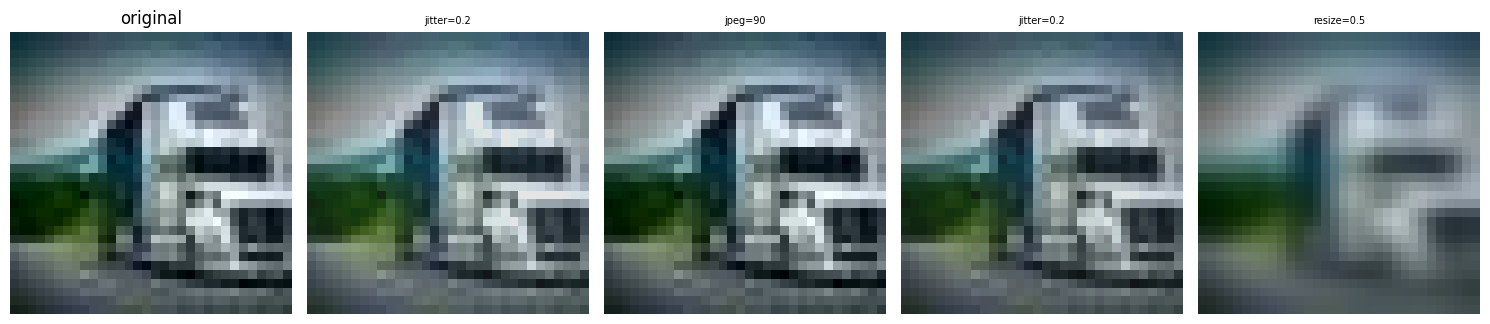

In [12]:
#CELL 13

import matplotlib.pyplot as plt

raw = datasets.ImageFolder(f'{data_path}/test')     # no transform → PIL
img, _ = raw[0]

fig, ax = plt.subplots(1, 5, figsize=(15, 3.5))
ax[0].imshow(img); ax[0].set_title('original'); ax[0].axis('off')
for i in range(1, 5):
    d, prm = random_chain(img, random.Random(i))
    ax[i].imshow(d); ax[i].axis('off')
    ax[i].set_title(', '.join(f'{k}={v}' for k, v in prm.items()), fontsize=7)
plt.tight_layout()

In [13]:
#CELL 14

class MultiView(torch.utils.data.Dataset):
    """K views per source image. View 0 is clean, 1..K-1 are degraded."""
    def __init__(self, folder, k=5, n_src=None, seed=0):
        self.base = datasets.ImageFolder(folder)
        if n_src:
            self.src_idx = np.random.RandomState(seed).choice(
                len(self.base), n_src, replace=False)
        else:
            self.src_idx = np.arange(len(self.base))
        self.k, self.seed = k, seed

    def __len__(self):
        return len(self.src_idx) * self.k

    def __getitem__(self, i):
        s, v = divmod(i, self.k)
        img, y = self.base[self.src_idx[s]]
        if v > 0:
            rng = random.Random(self.seed * 1_000_003 + i)   # deterministic
            img, _ = random_chain(img, rng)
        return tf(img), y, s, v

In [14]:
#CELL 15

from torch.utils.data import DataLoader, Subset

@torch.no_grad()
def cache_mv(folder, name, k=5, n_src=2000, flip=True, seed=0):
    ds = MultiView(folder, k=k, n_src=n_src, seed=seed)
    loader = DataLoader(ds, batch_size=128, num_workers=2)
    E, Y, S, V = [], [], [], []
    for i, (x, y, s, v) in enumerate(loader):
        E.append(model(x.cuda()).cpu().numpy())
        Y.append(y.numpy()); S.append(s.numpy()); V.append(v.numpy())
        if i % 10 == 0: print(f'{name}: batch {i}/{len(loader)}')
    E, Y = np.concatenate(E), np.concatenate(Y)
    if flip: Y = 1 - Y                       # CIFAKE only; SID_Set is already AI=1
    S, V = np.concatenate(S), np.concatenate(V)
    np.savez(f'{WORK}/{name}_mv.npz', emb=E, label=Y, img_id=S, view=V)
    return E, Y, S, V

NAME = 'cifake_train_10k'
p = f'{WORK}/{NAME}_mv.npz'

if os.path.exists(p):
    d = np.load(p)
    Etr5, Ytr5, Str5, Vtr5 = d['emb'], d['label'], d['img_id'], d['view']
    print('loaded from cache:', Etr5.shape)
else:
    Etr5, Ytr5, Str5, Vtr5 = cache_mv(f'{data_path}/train', NAME, k=5, n_src=10000)

# sanity check
print('sources:', Str5.max() + 1, '| views:', np.bincount(Vtr5), '| labels:', np.bincount(Ytr5))

cifake_train_10k: batch 0/391
cifake_train_10k: batch 10/391
cifake_train_10k: batch 20/391
cifake_train_10k: batch 30/391
cifake_train_10k: batch 40/391
cifake_train_10k: batch 50/391
cifake_train_10k: batch 60/391
cifake_train_10k: batch 70/391
cifake_train_10k: batch 80/391
cifake_train_10k: batch 90/391
cifake_train_10k: batch 100/391
cifake_train_10k: batch 110/391
cifake_train_10k: batch 120/391
cifake_train_10k: batch 130/391
cifake_train_10k: batch 140/391
cifake_train_10k: batch 150/391
cifake_train_10k: batch 160/391
cifake_train_10k: batch 170/391
cifake_train_10k: batch 180/391
cifake_train_10k: batch 190/391
cifake_train_10k: batch 200/391
cifake_train_10k: batch 210/391
cifake_train_10k: batch 220/391
cifake_train_10k: batch 230/391
cifake_train_10k: batch 240/391
cifake_train_10k: batch 250/391
cifake_train_10k: batch 260/391
cifake_train_10k: batch 270/391
cifake_train_10k: batch 280/391
cifake_train_10k: batch 290/391
cifake_train_10k: batch 300/391
cifake_train_10k: b

In [15]:
#CELL 16

clf_aug = LogisticRegression(max_iter=2000).fit(Etr5, Ytr5)

print('clean-trained, clean test:', roc_auc_score(Yte, clf.predict_proba(Ete)[:,1]))
print('aug-trained,   clean test:', roc_auc_score(Yte, clf_aug.predict_proba(Ete)[:,1]))

import joblib
joblib.dump(clf_aug, f'{WORK}/clf_aug.joblib')

clean-trained, clean test: 0.9805138246244216
aug-trained,   clean test: 0.9800098200883807


['/content/drive/MyDrive/aigc_detect/clf_aug.joblib']

In [16]:
#CELL 17
from sklearn.metrics import accuracy_score

class OneTransform(torch.utils.data.Dataset):
    def __init__(self, folder, op=None, sev=None, n=1500, seed=0):
        self.base = datasets.ImageFolder(folder)
        self.idx = np.random.RandomState(seed).choice(len(self.base), n, replace=False)
        self.op, self.sev = op, sev
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        img, y = self.base[self.idx[i]]
        if self.op: img = OPS[self.op][0](img, self.sev)
        return tf(img), y

@torch.no_grad()
def embed(ds):
    loader = DataLoader(ds, batch_size=128, num_workers=2)
    E, Y = [], []
    for x, y in loader:
        E.append(model(x.cuda()).cpu().numpy()); Y.append(y.numpy())
    return np.concatenate(E), 1 - np.concatenate(Y)

CONDITIONS = [('clean', None, None)] + [
    (f'{op}_{s}', op, s) for op, (_, sevs) in OPS.items() if op != 'screen'
    for s in sevs
]

def evaluate(clf, folder, n=1500):
    rows = []
    for name, op, sev in CONDITIONS:
        E, Y = embed(OneTransform(folder, op, sev, n=n))
        p = clf.predict_proba(E)[:, 1]
        rows.append((name, accuracy_score(Y, p > 0.5), roc_auc_score(Y, p)))
        print(f'{name:14s}  acc {rows[-1][1]:.4f}   auc {rows[-1][2]:.4f}')
    clean  = [r[2] for r in rows if r[0] == 'clean'][0]
    robust = np.mean([r[2] for r in rows if r[0] != 'clean'])
    print(f'\nAUC_clean {clean:.4f} | AUC_robust {robust:.4f} '
          f'| FINAL {0.5*clean + 0.5*robust:.4f}')
    return rows


print('=== clean-trained ===')
rows_base = evaluate(clf,     f'{data_path}/test')
print('\n=== aug-trained ===')
rows_aug  = evaluate(clf_aug, f'{data_path}/test')

=== clean-trained ===
clean           acc 0.9380   auc 0.9811
jpeg_90         acc 0.9307   auc 0.9795
jpeg_70         acc 0.9340   auc 0.9792
jpeg_50         acc 0.8920   auc 0.9696
jpeg_30         acc 0.8440   auc 0.9545
blur_0.5        acc 0.8887   auc 0.9716
blur_1.0        acc 0.6853   auc 0.9305
blur_2.0        acc 0.6113   auc 0.8410
resize_0.5      acc 0.6273   auc 0.9018
resize_0.25     acc 0.5480   auc 0.7978
noise_0.02      acc 0.8873   auc 0.9595
noise_0.05      acc 0.7493   auc 0.9404
noise_0.1       acc 0.5780   auc 0.8976
jitter_0.2      acc 0.9353   auc 0.9801
crop_0.8        acc 0.8100   auc 0.9588

AUC_clean 0.9811 | AUC_robust 0.9330 | FINAL 0.9570

=== aug-trained ===
clean           acc 0.9280   auc 0.9791
jpeg_90         acc 0.9260   auc 0.9784
jpeg_70         acc 0.9260   auc 0.9780
jpeg_50         acc 0.9220   auc 0.9778
jpeg_30         acc 0.8927   auc 0.9686
blur_0.5        acc 0.9107   auc 0.9746
blur_1.0        acc 0.8927   auc 0.9582
blur_2.0        acc 0.84

In [17]:
#CELL 18

PASSPORT_VIEWS = [                 # FIXED, not random — scores must compare
    ('clean',    lambda im: im),
    ('jpeg50',   lambda im: t_jpeg(im, 50)),
    ('blur1',    lambda im: t_blur(im, 1.0)),
    ('resize50', lambda im: t_resize(im, 0.5)),
    ('noise05',  lambda im: t_noise(im, 0.05)),
]

@torch.no_grad()
def passport(pil_img, clf):
    views = [fn(pil_img) for _, fn in PASSPORT_VIEWS]
    batch = torch.stack([tf(v) for v in views]).cuda()   # ONE forward pass
    embs  = model(batch).cpu().numpy()                   # (5, 768)
    s     = clf.predict_proba(embs)[:, 1]
    return {
        'pred':      float(s.mean()),
        'stability': float(1.0 - s.std()),
        'per_view':  {n: float(v) for (n, _), v in zip(PASSPORT_VIEWS, s)},
    }

raw = datasets.ImageFolder(f'{data_path}/test')
print(passport(raw[0][0], clf_aug))

{'pred': 0.9616882402277946, 'stability': 0.9644406408959095, 'per_view': {'clean': 0.8986544049847319, 'jpeg50': 0.946984623638367, 'blur1': 0.9955436307758654, 'resize50': 0.9870842855416547, 'noise05': 0.9801742561983547}}


In [18]:
#CELL 19

class PassportViews(torch.utils.data.Dataset):
    """Emits all 5 views of each image, flattened."""
    def __init__(self, folder, n=1000, seed=0):
        self.base = datasets.ImageFolder(folder)
        self.idx = np.random.RandomState(seed).choice(len(self.base), n, replace=False)
        self.k = len(PASSPORT_VIEWS)
    def __len__(self):
        return len(self.idx) * self.k
    def __getitem__(self, i):
        s, v = divmod(i, self.k)
        img, y = self.base[self.idx[s]]
        img = PASSPORT_VIEWS[v][1](img)
        return tf(img), y, s

@torch.no_grad()
def passport_batch(folder, clf, n=1000, seed=0):
    ds = PassportViews(folder, n=n, seed=seed)
    loader = DataLoader(ds, batch_size=128, num_workers=2)
    E, Y, S = [], [], []
    for x, y, s in loader:
        E.append(model(x.cuda()).cpu().numpy()); Y.append(y.numpy()); S.append(s.numpy())
    E, Y, S = np.concatenate(E), 1 - np.concatenate(Y), np.concatenate(S)

    scores = clf.predict_proba(E)[:, 1]
    k = len(PASSPORT_VIEWS)
    scores = scores.reshape(-1, k)        # (n, 5) — one row per source image
    labels = Y.reshape(-1, k)[:, 0]       # all 5 views share a label

    return {
        'pred':      scores.mean(axis=1),
        'stability': 1.0 - scores.std(axis=1),
        'single':    scores[:, 0],        # clean view only, for comparison
        'label':     labels,
    }

r = passport_batch(f'{data_path}/test', clf_aug, n=1000)

In [19]:
#CELL 20

# Q1: does averaging 5 views beat a single prediction?
print('single view :', roc_auc_score(r['label'], r['single']))
print('5-view mean :', roc_auc_score(r['label'], r['pred']))

# Q2: is stability actually a trust signal?
hi = r['stability'] > np.median(r['stability'])
print('\nAUC, stable half  :', roc_auc_score(r['label'][hi],  r['pred'][hi]))
print('AUC, unstable half:', roc_auc_score(r['label'][~hi], r['pred'][~hi]))

single view : 0.9785409098910243
5-view mean : 0.9852818805908052

AUC, stable half  : 0.9976737097110587
AUC, unstable half: 0.953781039282898


In [20]:
#CELL 21

import json, glob, os
import numpy as np

EXTS = ('*.jpg', '*.jpeg', '*.png', '*.bmp', '*.webp')

@torch.no_grad()
def predict_dir(folder, clf, out_path='preds.json', batch_size=64, limit=None):
    paths = []
    for e in EXTS:
        paths += glob.glob(os.path.join(folder, '**', e), recursive=True)
    paths = sorted(set(paths))
    if limit:
        paths = paths[:limit]
    if not paths:
        raise ValueError(f'no images found under {folder}')

    k = len(PASSPORT_VIEWS)
    rows = []

    for start in range(0, len(paths), batch_size):
        chunk = paths[start:start + batch_size]
        tensors, keep = [], []
        for p in chunk:
            try:
                img = Image.open(p).convert('RGB')
            except Exception as ex:
                print(f'skip {p}: {ex}')
                continue
            tensors += [tf(fn(img)) for _, fn in PASSPORT_VIEWS]
            keep.append(p)
        if not keep:
            continue

        embs = model(torch.stack(tensors).cuda()).cpu().numpy()
        s = clf.predict_proba(embs)[:, 1].reshape(len(keep), k)

        for p, row in zip(keep, s):
            rows.append({
                'image_path': p,
                'pred':       round(float(row.mean()), 6),
                'stability':  round(float(1.0 - row.std()), 6),
            })
        print(f'{len(rows)}/{len(paths)}')

    with open(out_path, 'w') as f:
        json.dump(rows, f, indent=1)
    print(f'wrote {len(rows)} predictions → {out_path}')
    return rows


# --- smoke test: 100 images, both classes ---
rows = predict_dir(f'{data_path}/test', clf_aug,
                   out_path=f'{WORK}/preds.json', limit=100)

fake = [r['pred'] for r in rows if '/FAKE/' in r['image_path']]
real = [r['pred'] for r in rows if '/REAL/' in r['image_path']]
print(f'\nFAKE mean {np.mean(fake):.3f}  (n={len(fake)})' if fake else '\nno FAKE sampled')
print(f'REAL mean {np.mean(real):.3f}  (n={len(real)})' if real else 'no REAL sampled')
print(rows[0])

64/100
100/100
wrote 100 predictions → /content/drive/MyDrive/aigc_detect/preds.json

FAKE mean 0.893  (n=100)
no REAL sampled
{'image_path': '/kaggle/input/cifake-real-and-ai-generated-synthetic-images/test/FAKE/0 (10).jpg', 'pred': 0.964418, 'stability': 0.962647}
